# Daily Positions Analysis

Analyze daily position snapshots from backtest to debug strategy behavior.

In [7]:
from pathlib import Path  # noqa: I001
import pandas as pd

# Load daily positions data
LOGS_DIR = Path("../logs")
df = pd.read_csv(LOGS_DIR / "daily_positions_20260202_093021.csv")
df["date"] = pd.to_datetime(df["date"]).dt.date.astype(str)
print(f"Loaded {len(df)} position records")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Loaded 9810 position records
Date range: 2025-01-02 to 2025-09-30


,date,equity,symbol,instrument_id,side,quantity,price,notional
0,2025-01-02,99960.800612,AAVE,AAVEUSDT-PERP.HYPERLIQUID,SHORT,-13.362693,320.20,-4278.734343
1,2025-01-02,99960.800612,ADA,ADAUSDT-PERP.HYPERLIQUID,LONG,5957.056403,0.92,5480.491891
2,2025-01-02,99960.800612,APT,APTUSDT-PERP.HYPERLIQUID,LONG,304.452641,9.02,2746.162821
3,2025-01-02,99960.800612,AVAX,AVAXUSDT-PERP.HYPERLIQUID,LONG,126.976871,37.79,4798.455942
4,2025-01-02,99960.800612,BNB,BNBUSDT-PERP.HYPERLIQUID,SHORT,-0.324040,707.83,-229.365538


## Equity Curve

<Axes: title={'center': 'Equity Curve'}, xlabel='date'>

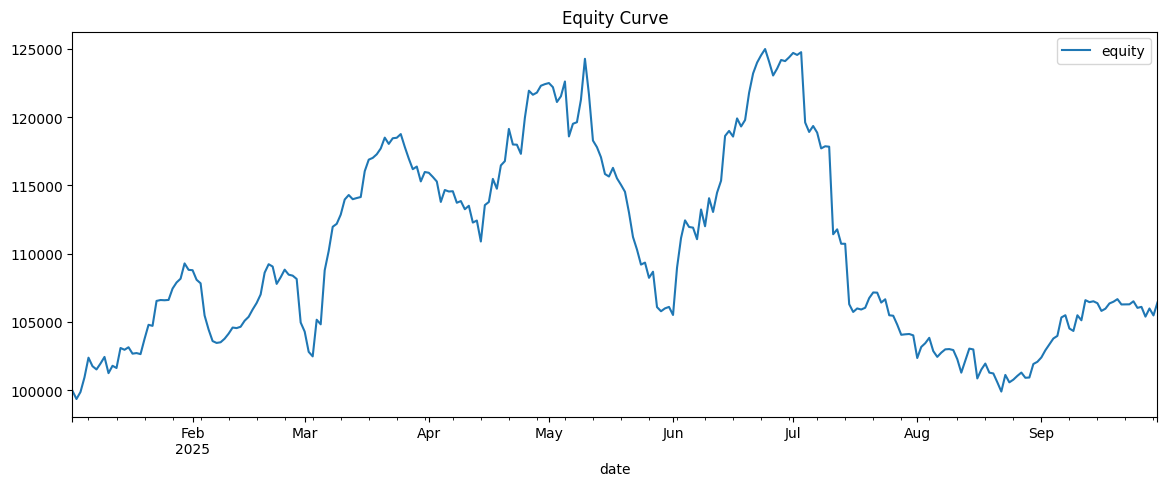

In [8]:
# Daily equity (one value per day)
daily_equity = df.groupby("date")["equity"].first().reset_index()
daily_equity["date"] = pd.to_datetime(daily_equity["date"])
daily_equity.plot(x="date", y="equity", figsize=(14, 5), title="Equity Curve")

## July 2025 Analysis (Drawdown Period)

In [9]:
# See positions on July 1, 2025
july1 = df[df["date"] == "2025-07-01"]
print(f"Positions on July 1, 2025: {len(july1)}")
july1

Positions on July 1, 2025: 37


,date,equity,symbol,instrument_id,side,quantity,price,notional
6537,2025-07-01,124706.441977,AAVE,AAVEUSDT-PERP.HYPERLIQUID,SHORT,-14.589055,274.38,-4002.945026
6538,2025-07-01,124706.441977,ADA,ADAUSDT-PERP.HYPERLIQUID,LONG,12469.827528,0.57,7107.801691
6539,2025-07-01,124706.441977,APT,APTUSDT-PERP.HYPERLIQUID,SHORT,-1326.198142,4.89,-6485.108914
6540,2025-07-01,124706.441977,ARB,ARBUSDT-PERP.HYPERLIQUID,SHORT,-1335.453188,0.34,-454.054084
6541,2025-07-01,124706.441977,AVAX,AVAXUSDT-PERP.HYPERLIQUID,LONG,206.554571,17.97,3711.785635
6542,2025-07-01,124706.441977,BCH,BCHUSDT-PERP.HYPERLIQUID,SHORT,-2.260018,505.49,-1142.416372
6543,2025-07-01,124706.441977,BNB,BNBUSDT-PERP.HYPERLIQUID,LONG,5.244083,656.63,3443.422115
6544,2025-07-01,124706.441977,BTC,BTCUSDT-PERP.HYPERLIQUID,LONG,0.048343,107140.50,5179.473906
6545,2025-07-01,124706.441977,CRV,CRVUSDT-PERP.HYPERLIQUID,SHORT,-1181.958663,0.52,-614.618505
6546,2025-07-01,124706.441977,DOGE,DOGEUSDT-PERP.HYPERLIQUID,SHORT,-5702.504592,0.17,-969.425781


In [10]:
# See equity over July 2025
july_equity = df[df["date"].str.startswith("2025-07")].groupby("date")["equity"].first()
print("Equity during July 2025:")
print(july_equity)

Equity during July 2025:
date
2025-07-01    124706.441977
2025-07-02    124559.459054
2025-07-03    124760.756288
2025-07-04    119615.447430
2025-07-05    118918.460811
2025-07-06    119354.571820
2025-07-07    118871.137916
2025-07-08    117715.431586
2025-07-09    117870.837975
2025-07-10    117839.674176
2025-07-11    111429.063182
2025-07-12    111788.286064
2025-07-13    110733.559688
2025-07-14    110731.382317
2025-07-15    106307.069800
2025-07-16    105738.237718
2025-07-17    105995.551841
2025-07-18    105917.843606
2025-07-19    106045.433935
2025-07-20    106756.381765
2025-07-21    107166.177455
2025-07-22    107152.403146
2025-07-23    106427.254609
2025-07-24    106666.637323
2025-07-25    105497.047844
2025-07-26    105461.012305
2025-07-27    104810.205360
2025-07-28    104067.133051
2025-07-29    104102.038817
2025-07-30    104125.094271
2025-07-31    104024.531285
Name: equity, dtype: float64


In [5]:
# See which symbols you were holding in July
july_symbols = df[df["date"].str.startswith("2025-07")]["symbol"].unique()
print(f"Symbols held in July 2025 ({len(july_symbols)} total):")
print(sorted(july_symbols))

Symbols held in July 2025 (49 total):
['AAVE', 'ADA', 'ALGO', 'APT', 'ARB', 'AVAX', 'BCH', 'BNB', 'BTC', 'CAKE', 'CFX', 'CRV', 'DOGE', 'DOT', 'ENA', 'ETC', 'ETH', 'ETHFI', 'FET', 'FTM', 'HBAR', 'HYPER', 'LDO', 'LINK', 'LTC', 'MOVE', 'NEAR', 'OM', 'ONDO', 'OP', 'PAXG', 'PENGU', 'PNUT', 'S', 'SEI', 'SOL', 'SUI', 'SYRUP', 'TAO', 'TIA', 'TON', 'TRUMP', 'TRX', 'UNI', 'VIRTUAL', 'WIF', 'WLD', 'XLM', 'XRP']


## Position Details for a Specific Date

In [6]:
# Change this date to analyze different days
TARGET_DATE = "2025-07-15"

day_positions = df[df["date"] == TARGET_DATE].copy()
if len(day_positions) > 0:
    print(f"Positions on {TARGET_DATE}:")
    print(f"Equity: ${day_positions['equity'].iloc[0]:,.2f}")
    print(f"Number of positions: {len(day_positions)}")
    print()
    display(day_positions.sort_values("notional", key=abs, ascending=False))
else:
    print(f"No data for {TARGET_DATE}")

Positions on 2025-07-15:
Equity: $11,665.40
Number of positions: 35



,date,equity,symbol,instrument_id,side,quantity,price,notional
7106,2025-07-15,11665.395682,XLM,XLMUSDT-PERP.HYPERLIQUID,SHORT,-1687.029864,0.46,-776.033738
7081,2025-07-15,11665.395682,ENA,ENAUSDT-PERP.HYPERLIQUID,SHORT,-1820.453418,0.34,-618.954162
7092,2025-07-15,11665.395682,PNUT,PNUTUSDT-PERP.HYPERLIQUID,SHORT,-2039.356720,0.27,-550.626314
7102,2025-07-15,11665.395682,UNI,UNIUSDT-PERP.HYPERLIQUID,LONG,57.856639,9.14,528.809685
7079,2025-07-15,11665.395682,BTC,BTCUSDT-PERP.HYPERLIQUID,LONG,0.004398,119967.50,527.577476
7073,2025-07-15,11665.395682,AAVE,AAVEUSDT-PERP.HYPERLIQUID,LONG,1.637784,315.41,516.573600
7094,2025-07-15,11665.395682,SOL,SOLUSDT-PERP.HYPERLIQUID,LONG,3.082724,162.31,500.357012
7076,2025-07-15,11665.395682,AVAX,AVAXUSDT-PERP.HYPERLIQUID,LONG,22.190062,21.27,471.982612
7074,2025-07-15,11665.395682,ADA,ADAUSDT-PERP.HYPERLIQUID,LONG,595.789675,0.74,440.884359
7082,2025-07-15,11665.395682,ETH,ETHUSDT-PERP.HYPERLIQUID,LONG,0.143672,3016.65,433.409315


## Track a Specific Symbol Over Time

BTC position history (272 days):


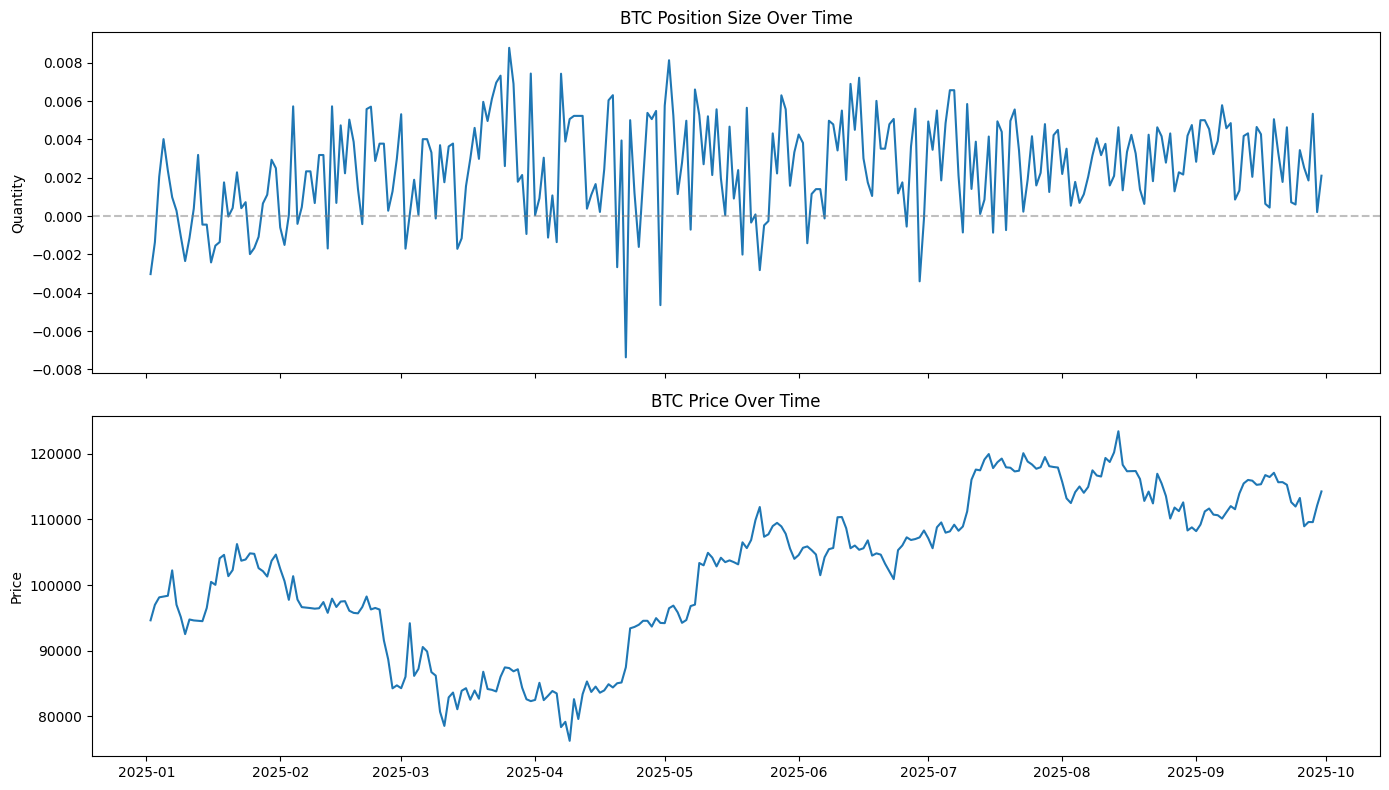

In [9]:
import matplotlib.pyplot as plt

# This cell should be run before the symbol tracking cell above
plt.style.use('default')

# Change this to track different symbols
TARGET_SYMBOL = "BTC"

symbol_history = df[df["symbol"] == TARGET_SYMBOL].copy()
if len(symbol_history) > 0:
    symbol_history["date"] = pd.to_datetime(symbol_history["date"])
    print(f"{TARGET_SYMBOL} position history ({len(symbol_history)} days):")
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    axes[0].plot(symbol_history["date"], symbol_history["quantity"])
    axes[0].set_ylabel("Quantity")
    axes[0].set_title(f"{TARGET_SYMBOL} Position Size Over Time")
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    axes[1].plot(symbol_history["date"], symbol_history["price"])
    axes[1].set_ylabel("Price")
    axes[1].set_title(f"{TARGET_SYMBOL} Price Over Time")
    
    plt.tight_layout()
else:
    print(f"No position history for {TARGET_SYMBOL}")

## Long vs Short Exposure Analysis

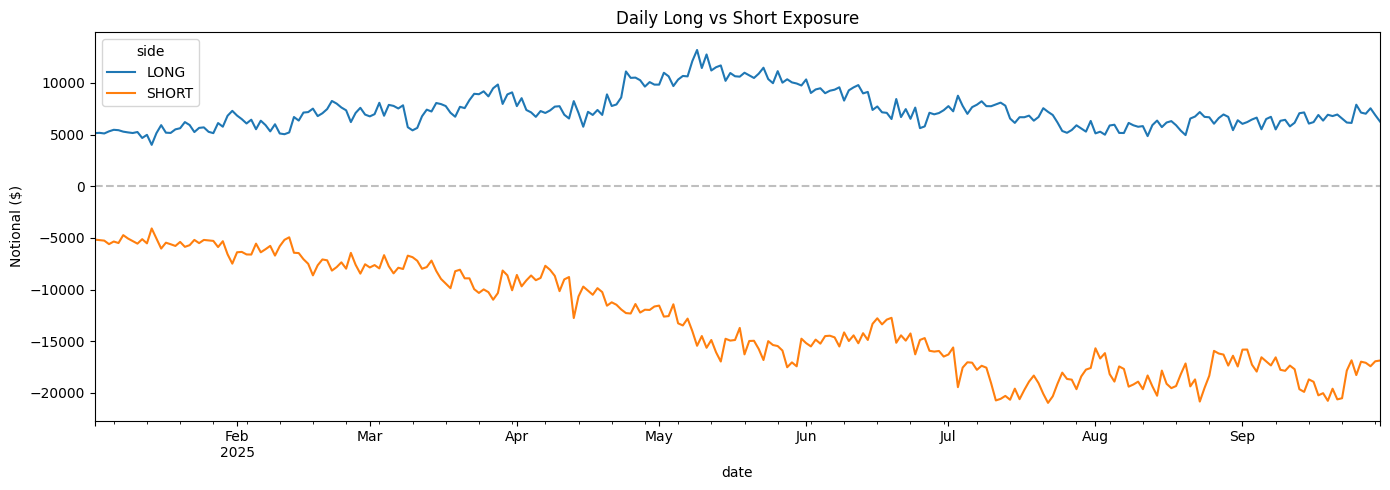

In [10]:
# Calculate daily long/short exposure
exposure = df.groupby(["date", "side"])["notional"].sum().unstack(fill_value=0)
exposure["net"] = exposure.get("LONG", 0) + exposure.get("SHORT", 0)
exposure["gross"] = exposure.get("LONG", 0).abs() + exposure.get("SHORT", 0).abs()
exposure.index = pd.to_datetime(exposure.index)

fig, ax = plt.subplots(figsize=(14, 5))
exposure[["LONG", "SHORT"]].plot(ax=ax, title="Daily Long vs Short Exposure")
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel("Notional ($)")
plt.tight_layout()